# 循环神经网络

## 背景

对于普通神经网络，例如多层感知机，其**前一个输入和后一个输入完全没有联系**，导致在处理时间序列问题时，难以精准刻画时间序列中的时间关系。

为了更好地处理时间序列问题，学者提出了循环神经网络结构（Recurrent Neural Network），最基本的循环神经网络由输入层、一个隐藏层和一个输出层组成。

## RNN 简介

循环神经网络结构（Recurrent Neural Network）

![image-20250510094123603](markdown-img/循环神经网络.assets/image-20250510094123603.png)

解释：

- X：输入层的值
- U：输入到隐藏层的权重矩阵
- V：隐藏层到输出层的权重矩阵
- O：输出层
- S：是一个向量，表示隐藏层的值，其不仅仅取决于当前的输入X，**还取决于上一时刻隐藏层的值**。如果去掉有W的带箭头的连接线，即为普通的全连接神经网络。
- W：隐藏层上一时刻的值，作为当前时刻输入的权重矩阵

公式：

![image-20250510094337867](markdown-img/循环神经网络.assets/image-20250510094337867.png)

解释：

+ f即为激活函数

把RNN结构按照时间线展开。（Elman）

![image-20250510094424957](markdown-img/循环神经网络.assets/image-20250510094424957.png)

若只要一个输出，不要Ot、Ot-1即可。

![image-20250510094903687](markdown-img/循环神经网络.assets/image-20250510094903687.png)

RNN与基础的神经网络最大的不同之处在于**同一层内的神经元在不同时刻也建立了全连接**，即W与时间有关。

## LSTM

LSTM（Long Short-Term Memory）模型，属于RNN的一种。

循环神经网络图LSTM

![image-20250510100727781](markdown-img/循环神经网络.assets/image-20250510100727781.png)

![image-20250510095939720](markdown-img/循环神经网络.assets/image-20250510095939720.png)

### 与RNN区别

RNN和LSTM最大区别在于分布在隐藏层的神经元结构。

LSTM的记忆单元（Block）更加复杂，**LSTM模型中增加了状态𝑐**，称为单元状态（cell state），用来**保存长期的状态**，而LSTM的关键，就是怎样控制长期状态

### LSTM的重复模块

真实图：

![image-20250510100021713](markdown-img/循环神经网络.assets/image-20250510100021713.png)

公式：

![image-20250510100052578](markdown-img/循环神经网络.assets/image-20250510100052578.png)

LSTM的核心是单元的状态，单元状态的传递类似于传送带，直接在整个时间链上运行，中间值有一些少量的线性交互，便于保存相关信息。

### 实现

1. 导包

In [ ]:
from torch import nn
from torch.autograd import Variable
import torch

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

2. 数据展示

In [1]:
file_path = './LSTM.csv'
data = pd.read_csv(file_path)
data.dropna(inplace=True)
plt.plot(data)
plt.show()

NameError: name 'pd' is not defined

3. 数据归一化

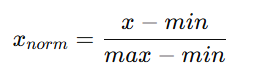

In [ ]:
# 归一化 所有数据缩放到 0和1之间
data_ndarray = data.values
data_ndarray = data_ndarray.astype('float32')
max_num = np.max(data_ndarray)
min_num = np.min(data_ndarray)
scalar = max_num - min_num

dataset = list(map(lambda x: (x - min_num)/scalar,data_ndarray))

4. 初始化训练和测试数据

In [ ]:
'''
初始化数据
把前2个时间粒度的客流数据作为输入,把当前时间粒度的客流数据作为输出
返回：测试集、训练集
'''
def create_dataset(data,step=5, train_percent=0.7):
    dataX = []
    dataY = []
    data_len = len(data)
    for i in np.arange(data_len - step):
        split_num = i+step
        dataX.append(data[i:split_num])
        dataY.append(data[split_num])

    # 区分测试、训练集
    dataX_len = len(dataX)
    dataY_len = len(dataY)
    split_index = int(dataX_len * train_percent)
    
    trainX = torch.from_numpy(np.array(dataX[:split_index]).reshape(-1,1,5))
    trainY = torch.from_numpy(np.array(dataY[:split_index]).reshape(-1,1,1))
    testX = torch.from_numpy(np.array(dataX[split_index:]).reshape(-1,1,5))
    testY = torch.from_numpy(np.array(dataY[split_index:]).reshape(-1,1,1))

    return trainX, trainY, testX, testY

trainX, trainY, testX, testY = create_dataset(dataset)

5. 建立模型

In [ ]:
class LSTM_LINEAR(nn.Module):
    def __init__(self, input_size, hidden_size, output_size=1, num_layers=2):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers)
        self.linear = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        x, _ = self.lstm(x) # (seq, batch, hidden)
        s,b,h = x.shape
        # 降维，匹配linear参数要求
        x = x.view(s*b, h)
        x = self.linear(x) # input:(*, Hin), Hin即 hidden_size
        x = x.view(s,b,-1)
        return x

# 实例化
net = LSTM_LINEAR(5,45)
# 损失
criterion = nn.MSELoss()
# 优化器
optimizer = torch.optim.Adam(net.parameters(), lr=1e-2)

6. 训练

In [ ]:
# 训练
for e in range(200):
    out = net(trainX)
    loss = criterion(out, trainY)
    # 梯度清零
    optimizer.zero_grad()
    loss.backward()
    # 更新模型参数
    optimizer.step()
    if e%10==0:
        print(f'epoch: {e}, loss: {loss.item()}')

7. 测试

In [ ]:
# 转为测试模式
net = net.eval()
with torch.no_grad():
    out = net(testX)
    loss = criterion(out, testY)

print(f'sample is test, loss is {loss.item()}')

8. 预测并反归一化

In [ ]:
# 反归一化
def restore(x):
    return x.view(-1).data.numpy()*scalar +min_num

pre_testX = net(testX)
pre_testX_new = restore(pre_testX) # 预测值
testY_new = restore(testY) # 真实值

9. 画图

plt.figure(figsize=(6,4))
plt.plot(pre_testX_new, label='predict')
plt.plot(testY_new, label='real')

plt.show()